# Programming Assignment 4: CLIP: Connecting text and images

### Due Date:
May 4 at 11:59 PM

### Writeup:
Please make a copy to the google doc to fill in your answers

https://docs.google.com/document/d/1RmI5Cd2N0s_BxLcnbG_XL7Aai3ITJm-C3zvP9J7eUeY/edit?usp=sharing


# Introduction

Welcome to PA4 of CS4670/5670

Computer vision has traditionally relied on supervised learning with large labeled datasets for tasks such as object detection, image classification, and segmentation. But this approach has limitations, such as the need for extensive manual labeling and poor generalization to unseen concepts. OpenAI tries to tackle this problem with the Contrastive Language-Image Pretraining(CLIP) model. It presents a paradigm shift in how models understand and process visual information. CLIP is a multimodal neural network trained on a vast dataset of image-text pairs. Unlike conventional vision models that require fine-tuning for specific tasks, CLIP learns visual concepts directly from natural language descriptions. This allows it to generalize across a wide range of visual tasks without the need for task-specific labeled data. In PA4, we will leverage the generalizability of CLIP for some specific computer vision tasks. CLIP is particularly effective for zero-shot classification, image retrieval, and open-set recognition, enabling models to recognize objects and scenes without explicit training on a given dataset. Compared to supervised learning approaches, which require labeled training data and struggle with novel categories, CLIP performs inference based on textual descriptions, making it highly adaptable.


**Structure of Assignment:**
This assignment is built up by the following components:
1. Zero-shot recognition
2. Hand-crafted prompt tuning
3. Building a learnable text embedding model
4. Using the text embedding model for classification

Please read through the following paragraphs carefully.


**Getting Started:** This assignment is done on **[Google Colab](https://colab.research.google.com/)**. Note:
Each of you has been granted colab credit you can use for this project. If you need Google Cloud credits, please refer to [this post](https://edstem.org/us/courses/74190/discussion/6560576).

**Pros tip:**
1. When activate your credit, don't put your credit card information in, this will guarantee you don't get charged by accident.
2. Make sure to disconnect your session if you are not going to work on it for a while; at the same time, if you idle for too long, Colab could disconnect.


**Evaluation:**
Your code will be tested for correctness along with the writeup.

**Academic Integrity:** We will be checking your code against other submissions in the class for logical redundancy. If you copy someone else’s code and submit it with minor changes, we will know.

**Getting Help:** If you ever feel stuck in these projects, please feel free to avail yourself to office hours and Edstem!


***Here's a checklist of all the TODOs you need to complete:***

1.1. Classify image

2.1. Experiment with various text prompts

2.2.1., 2.2.2. Submit for writeup your prompts and observations

3.1.1., 3.1.2. Init and forward functions for CLIPWithLearnableEmbeddings

3.2.1, 3.2.2, 3.2.3, 3.2.4. Training/Finetuning and evaluation functions

3.5. Submit best_learnable_weights.pth to Gradescope

4.1.1., 4.1.2. Init and forward functions for CLIPClassifierFineTuner

Submit to CMSX: best_learnable_weights.pth and best_linear_weights.pth


## Setup - Upload files, install packages and load pre-trained CLIP

## TODO 0 : Upload "utils.py" and "mini_CUB.zip" to "./"

1. In Google Colab, click the folder icon (left sidebar).

2. Click the "Upload files" button.

3. Select utils.py and mini_CUB.zip from your local machine and upload them.

4. The files will appear in the /content/ directory.

Run the cell below to complete all the setup

In [ ]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git
import clip
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import zipfile
from utils import *

os.makedirs("./visualizations", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #checks for a GPU; defaults to CPU if unavailable.
print(f"Using device: {device}")

# Load the pre-trained CLIP model (Vision Transformer, B/32 variant) along with its image preprocessing pipeline.
clip_model, preprocess = clip.load("ViT-B/32", device=device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-kd3ojet0
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-kd3ojet0
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

100%|███████████████████████████████████████| 338M/338M [00:09<00:00, 38.6MiB/s]


## TODO 1 : Zero-shot Recognition

CLIP is a zero-shot model, which means that it can recognize concepts without explicitly being trained on them. We can do this by using CLIP to measure the similarity between an image and text descriptions of the possible labels.

For example, to classify an image into one of three categories, "cat", "dog" or "person", CLIP will measure the similarity between the image and each of the following three captions:
- "This is a photo of a cat"
- "This is a photo of a dog"
- "This is a photo of a person"

The caption that gives the highest similarity yields the predicted class.

In this section, we will perform this kind of classification with 2 different datasets -- **Imagenette** and **CUB 200**.
Imagenette is general category recognition, while CUB is specific to bird species (often called fine-grained recognition).


Let us first download the datasets, beginning with Imagenette. Run the following two cells (they have no TODOs).


In [ ]:
%%capture
# Download the dataset. This will take a few minutes
!wget https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz
!tar -xzvf imagenette2.tgz

# Create a pytorch dataset and a data loader.
# The dataset will behave like a list of (image, labelid) pairs.
imagenette_dataset = ImageFolder("imagenette2/val", transform=preprocess)
#dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


# The dataset uses class names that are from Wordnet.
# Let us convert them into human readable class names.
wnid_to_label = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute"
}
if imagenette_dataset.classes != ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']:
  imagenette_dataset.classes = [wnid_to_label[class_code] for class_code in imagenette_dataset.classes]


### Let's look at some Imagenette image and text pairs!

['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']


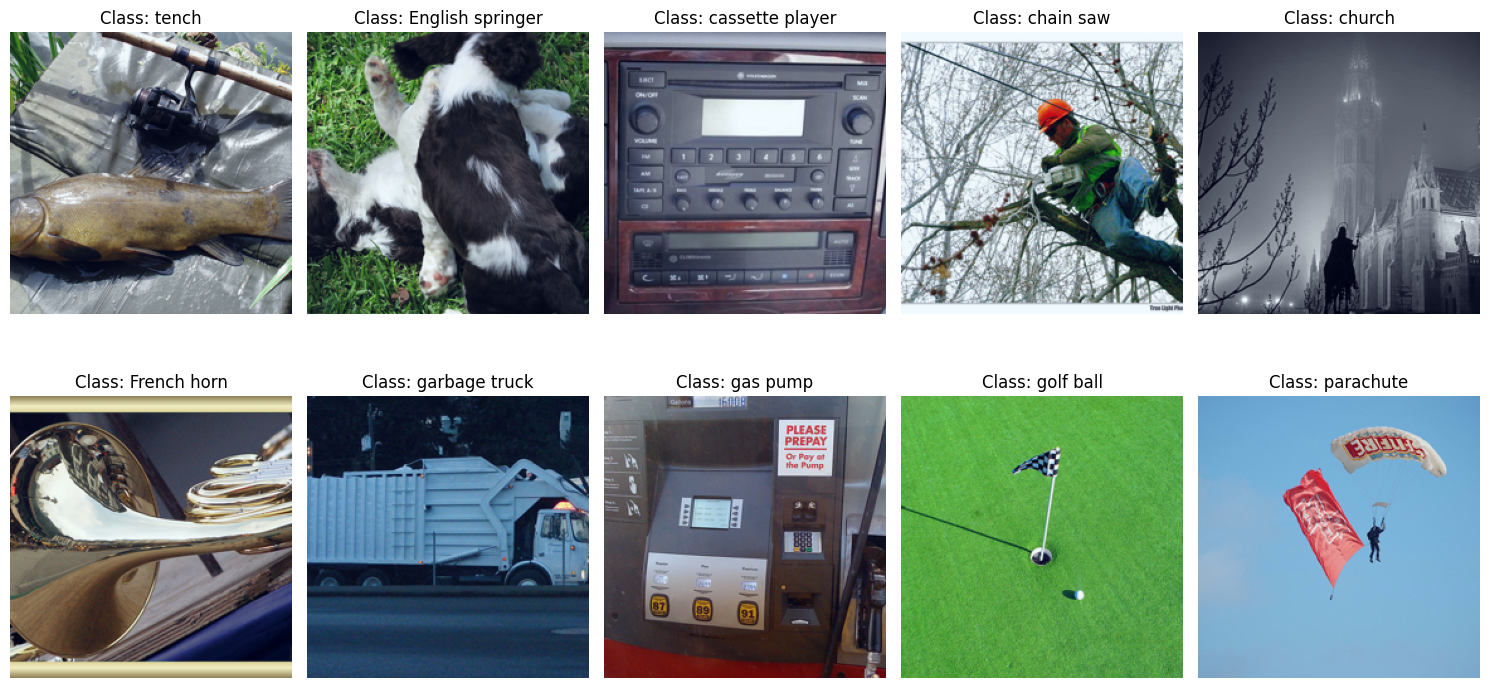

In [ ]:
print(imagenette_dataset.classes)

# Let us visualize the data!
visualize_samples(imagenette_dataset, imagenette_dataset.classes)

Next we will download CUB, which you have been given as a zip.

In [ ]:
# Define the zip file and extraction directory
zip_file = './mini_CUB.zip'
extract_dir = './'

# Check if the zip file exists before extracting
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted {zip_file} to {extract_dir}")
else:
    print(f"{zip_file} does not exist in {extract_dir}")

dataset_path = "./mini_CUB"

# Create the dataset.
cub_train_dataset = MiniCUB(dataset_path, split="train", transform=preprocess)
cub_test_dataset = MiniCUB(dataset_path, split="test", transform=preprocess)

# Again, let us convert the class names to human readable form.
num_classes = len(cub_train_dataset.classes)
class_names = [name.split(".")[1].replace("_", " ") for name in cub_train_dataset.classes]
cub_train_dataset.classes = class_names
cub_test_dataset.classes = class_names

Extracted ./mini_CUB.zip to ./


### Let's look at some CUB image and text pairs!

['Spotted Catbird', 'Green Jay', 'Clark Nutcracker', 'White necked Raven', 'American Redstart', 'Henslow Sparrow', 'Tree Sparrow', 'Artic Tern', 'Canada Warbler', 'Palm Warbler']


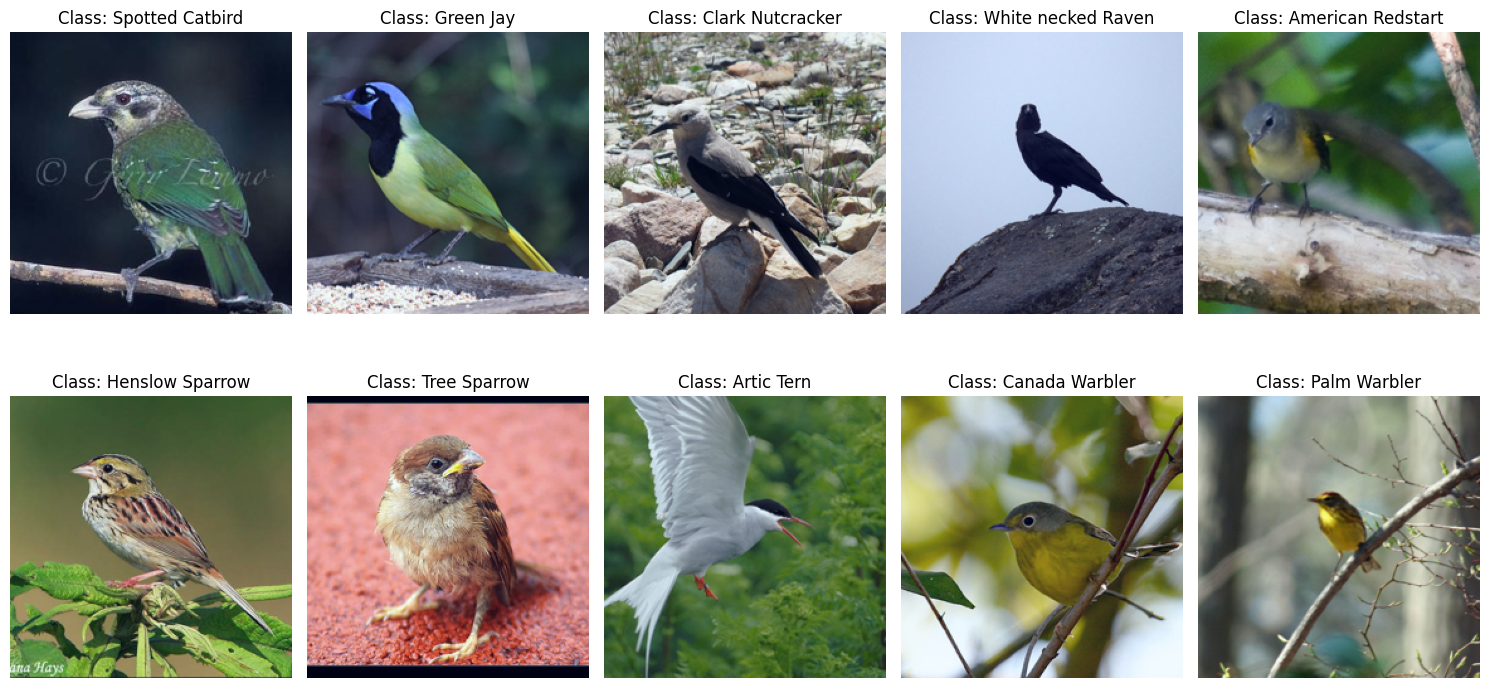

In [ ]:
print(class_names)
# Let us visualize the data!
visualize_samples(cub_train_dataset, cub_train_dataset.classes)

### TODOs

Here come your TODOs!

In this section, we will focus on using CLIP as an image classifier.

To do so, we simply compute the similarity between an image's CLIP embeddings and all class names's embeddings, and output the class that correspond to the highest similarity.

cosine_similarity(A,B)$=\frac{A⋅B}{||A||⋅||B||}$, where A and B is text and image embedding vector respectively.

#### TODO 1.1 : Write code that takes an image and a list of text descriptions as input, and outputs the id of the class that yields the highest similarity.

In [ ]:
def classify_image(clip_model, image, text_descriptions):
    '''
    Given an image and the embeddings of all possible classes, classify it using CLIP.

    Inputs:
        clip_model: the clip model loaded above
        image: 2D torch tensor
        text_descriptions: a list of possible text descriptions for the image

    Output:
        image_class: int representing the class number

    TODO 1.1.1:
        Steps:
        1. Move image to the same device (CPU or GPU) as the model.
        2. Add an extra dimension (batch dimension) to the image tensor.
        3. Extract image embeddings using clip_model's `encode_image` method.
        4. Normalize image embeddings.
        5. Tokenize text descriptions using clip's `tokenize` method.
        6. Extract text embeddings using clip_model's `encode_text` method.
        7. Normalize text embeddings.
        8. Compute the cosine similarity between image embeddings and text embeddings.
        9. Predict the class by choosing the text label with the highest similarity score and extract integer.

    Here are a set of pytorch functions that you might find useful to implement some operations above:
        1. .unsqueeze()
        2. .to()
        3. .norm()
        4. .argmax()
        5. .item()

    '''
    ### TODO ###
    device = next(clip_model.parameters()).device
    image = image.to(device).unsqueeze(0)

    with torch.no_grad():
        image_features = clip_model.encode_image(image)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        text_tokens = clip.tokenize(text_descriptions).to(device)
        text_features = clip_model.encode_text(text_tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ text_features.T
        image_class = similarity.argmax().item()
    ############

    return image_class

### Evaluation (no TODOs) ###
Let us now evaluate our classifier on **ImageNette** and **CUB**

The evaluation code will take **2-3** minutes using Colab GPU

In [ ]:
clip_model.eval()

# Imagenette evaluation

imagenette_text_descriptions = [f"This is a photo of a {label}" for label in imagenette_dataset.classes]
imagenette_predictions = [classify_image(clip_model, image, imagenette_text_descriptions) for (image, label) in tqdm(imagenette_dataset)]
true_labels = [label for (image, label) in imagenette_dataset]

correct = sum(p == t for p, t in zip(imagenette_predictions, true_labels))
total = len(true_labels)

print("Imagenette classification accuracy:")
print(f"Number correct: {correct}")
print(f"Total: {total}")
print(f"Accuracy: {correct/total}\n")


# CUB evaluation

cub_text_descriptions = [f"This is a photo of a {label}" for label in cub_test_dataset.classes]
cub_predictions = [classify_image(clip_model, image, cub_text_descriptions) for (image, label) in tqdm(cub_test_dataset)]
true_labels = [label for (image, label) in cub_test_dataset]

correct = sum(p == t for p, t in zip(cub_predictions, true_labels))
total = len(true_labels)

print("CUB classification accuracy:")
print(f"Number correct: {correct}")
print(f"Total: {total}")
print(f"Accuracy: {correct/total}")

Imagenette classification accuracy:
Number correct: 3878
Total: 3925
Accuracy: 0.9880254777070063

CUB classification accuracy:
Number correct: 46
Total: 50
Accuracy: 0.92


## TODO 2 : Improving text prompts ##

The performance of CLIP is dependent on the text prompts provided for each of the classes. In this exercise, you will gain some understanding of the types of text prompts that enables CLIP to perform at its best. We will try to improve CLIP performance on **CUB** by changing the prompts.

In the code cell with a list of custom prompts, modify the list and customize the descriptions of each of the classes. As you test different descriptions, try to understand certain kinds of descriptions that increases the test accuracy. Does color, size, or other descriptors help in increasing test accuracy?

#### TODO 2.1: Create a new set of prompts below that yields the best performance. Feel free to consult https://www.allaboutbirds.org/news/ to know more about the bird species in question.

*Hint: color, size, body parts are great descriptors*

*A final accuracy of at least 0.46 is expected for full credit*

***Note: you can't use the bird class names as part of your prompts, i.e. spotted catbird, green jay, etc.***

#### TODO 2.2 (Writeup):
2.2.1 Copy the prompts you came up with that produce the best result

2.2.2 What prompting strategies lead to the best performance and what strategies lead to worse performance?



In [ ]:
custom_class_descriptions = [
    # TODO 2.1: Define a list of custom text prompts for the birds.
    # Take a look at the visualization above to get a better idea of how they look like before writing your prompts.
    # Each prompt corresponds to a specific class label that the CLIP model will compare against image embeddings.
    # Ensure the prompts are descriptive and representative of the target categories.
    # ***NOTE:
    #    1. You can't use the bird class names as part of your prompts, i.e. spotted catbird, green jay, etc.
    #    2. A final accuracy of at least 0.46 is expected for full credit

    ### Example ###
    # "a Bharath called Bharath with a blue shirt on", # Class 1
    ### End of Example ###

    "a medium-sized bird with greenish-gray spotted plumage perched in dense foliage",           # Class 1 (018.Spotted_Catbird)
    "a brightly colored bird with vivid green wings, a blue head, and yellow underparts",        # Class 2 (075.Green_Jay)
    "a gray bird with black and white wings cracking open pine cones with a pointed bill",       # Class 3 (093.Clark_Nutcracker)
    "a large all-black bird with a distinctive white patch on the back of its neck",             # Class 4 (108.White_necked_Raven)
    "a small black bird with bright orange patches on its wings, tail, and sides",               # Class 5 (109.American_Redstart)
    "a tiny streaky sparrow with an olive-colored head and rufous-brown wings in tall grass",    # Class 6 (123.Henslow_Sparrow)
    "a small sparrow with a rufous-red cap and a dark spot on its white cheek patch",            # Class 7 (130.Tree_Sparrow)
    "a white seabird with a black cap, bright red bill, deeply forked tail, and long wings",     # Class 8 (141.Artic_Tern)
    "a small yellow-breasted bird with a gray back and a black necklace of streaks on its chest", # Class 9 (162.Canada_Warbler)
    "a small brownish warbler with a rusty cap, yellow undertail coverts, and a habit of bobbing its tail", # Class 10 (174.Palm_Warbler)
]

# Evaluate again
cub_predictions = [classify_image(clip_model, image, custom_class_descriptions) for (image, label) in cub_test_dataset]
true_labels = [label for (image, label) in cub_test_dataset]

correct = sum(p == t for p, t in zip(cub_predictions, true_labels))
total = len(true_labels)

print("CUB classification accuracy:")
print(f"Number correct: {correct}")
print(f"Total: {total}")
print(f"Accuracy: {correct/total}")

CUB classification accuracy:
Number correct: 25
Total: 50
Accuracy: 0.5


## TODO 3 : CLIP with Learnable Embeddings




You probably observed that hand-crafted prompt tuning requires manual trial-and-error, and it's quite tedious to design a effictive text description that align well with CLIP's learned representation. Now we are going to introduce a way to do this faster and better via Learnable Text Embeddings. Learnable embeddings automatically optimize text representations for a given task. The model adapts to an optimal set of embeddings that best align with the image data through training, removing bias and improving perfromance across tasks.

This module integrates a frozen CLIP model for image feature extraction with learnable class embeddings.


### TODO 3.1 Write the init and forward functions of the following class that uses CLIP weights to optimize for learnable class embeddings for our classification task.

<!-- Key steps:

- **Initialization:**  
  - Loads the pre-trained CLIP model and its preprocessing.  
  - Freezes all CLIP parameters to prevent updates during training.  
  - Initializes learnable embeddings for each class.

- **Forward Pass:**  
  - Extracts and normalizes image features using CLIP.  
  - Normalizes the learnable embeddings.  
  - Returns the class scores and the raw image features. -->
  

In [ ]:
class CLIPWithLearnableEmbeddings(nn.Module):
    """
    A wrapper around the CLIP image encoder with learnable class embeddings,
    allowing training on a fixed set of categories without using text prompts.

    Args:
        num_classes (int): Number of output classes.
        embedding_dim (int): Dimension of the CLIP image feature vectors (e.g., 512).
        clip_model (nn.Module): Pre-trained CLIP model (from clip.load()).

    Attributes:
        learnable_embeddings (nn.Parameter): Learnable class embeddings used to
        compute similarity with image features.
    """
    def __init__(self, clip_model, num_classes, embedding_dim=512):
        super(CLIPWithLearnableEmbeddings, self).__init__()
        self.clip_model = clip_model

        """
        TODO 3.1.1:
        Steps:
        1. Freeze CLIP parameters by setting `requires_grad` of all clip_model
        parameters to `False`.
        2. Initialize `self.learnable_embeddings` as a 'nn.Parameter' with data
        as a Torch Tensor of random numbers (hint: `torch.randn`). Think about
        what the size of this Tensor should be (hint: involves `num_classes` and
        `embedding_dim`).
        YOU MUST NAME YOUR VARIABLE `self.learnable_embeddings` to get full credit!!!!
        """
        ### TODO ###
        for param in self.clip_model.parameters():
            param.requires_grad = False
        self.learnable_embeddings = nn.Parameter(torch.randn(num_classes, embedding_dim))
        ############

    def forward(self, images):
        """
        Computes similarity scores between input images and learnable class embeddings.

        Args:
            images (torch.Tensor): Batch of preprocessed images (N x 3 x H x W).

        Returns:
            tuple:
                - class scores (torch.Tensor): (N x num_classes).
                - image_features (torch.Tensor): Normalized image feature vectors (N x embedding_dim).
        """

        """
        TODO 3.1.2:
        Steps:
        1. [ONLY FOR STEP 1] Turn off gradient calculation with `torch.no_grad`
            1.1. Extract the image features using CLIP's `encode_image` function
            1.2. Cast the image feature to a float Tensor
            1.3. Normalize the image features with `Tensor.norm`
        2. Normalize learnable embeddings from init. Ensure it's a float Tensor
        3. Compute class scores (aka cosine similarity), which is the dot
        product between normalized image features and normalized embeddings
        """
        ### TODO ###
        with torch.no_grad():
            image_features = self.clip_model.encode_image(images)
            image_features = image_features.float()
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        embeddings = self.learnable_embeddings.float()
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

        class_scores = image_features @ embeddings.T
        ############

        return class_scores, image_features

### TODO 3.2 : Training/Finetuning and Evaluation Functions
<!-- **Parameters:**
- `model`: Neural network model.
- `train_loader`: Training data batches.
- `optimizer`: Optimization algorithm.
- `epoch`: Current epoch number.

**Functionality:**
- Sets model to training mode: TODO
- Processes each batch: TODO
- Tracks cumulative loss and accuracy: TODO
- Prints and returns the average loss and accuracy. -->


In [ ]:
def train(model, train_loader, optimizer, epoch):
    """
    Trains the given model for one epoch using the provided data loader and optimizer.

    Args:
        model (torch.nn.Module): The model to train.
        train_loader (DataLoader): DataLoader providing the training data.
        optimizer (torch.optim.Optimizer): The optimizer used to update model parameters.
        epoch (int): The current epoch number (used for logging only).
    Parameters:
        total_loss: the total loss for the epoch.
        correct: the number of correctly classified samples.
        total: the total number of samples.

    Returns:
        tuple: A tuple containing:
            - avg_loss (float): The average loss over the epoch.
            - accuracy (float): The training accuracy as a percentage.
    """

    total_loss = 0.0
    correct = 0
    total = 0

    """
    TODO 3.2.1:
    Step:
    1. Set model to training mode
    """
    ### TODO ###
    model.train()
    ############

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
        images = images.to(device)
        labels = labels.to(device)

        """
        TODO 3.2.2:
        Steps:
        0. Don't forget to set model to training mode (TODO 3.2.1)
        1. Reset the gradients of all optimized Tensors with `zero_grad()`
        2. Forward pass; feed images through model and get class scores (logits)
        3. Compute loss; we're using cross entropy loss `F.cross_entropy`
        4. Backward pass and optimize
        5. Accumalate total and correct
        """
        ### TODO ###
        optimizer.zero_grad()
        class_scores, _ = model(images)
        loss = F.cross_entropy(class_scores, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = class_scores.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        ############

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total

    print(f"Train Epoch: {epoch}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    return avg_loss, accuracy

In [ ]:
def evaluate(model, test_loader):
    """
    Evaluates the given model for one epoch using the provided data loader.

    Args:
        model (torch.nn.Module): The model to evaluate.
        test_loader (DataLoader): DataLoader providing the testing data.
    Parameters:
        correct: the number of correctly classified samples.
        total: the total number of samples.

    Returns:
        tuple: A tuple containing:
            - accuracy (float): The training accuracy as a percentage.
            - all_preds (List of ):
            - all_labels (List of ):
            - all_features (List of):
    """
    correct = 0
    total = 0

    # For visualization
    all_preds = []
    all_labels = []
    all_features = []

    """
    TODO 3.2.3:
    Step:
    1. Set model to evaluation mode
    """
    ### TODO ###
    model.eval()
    ############

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)

            """
            TODO 3.3.4:
            Steps:
            0. Don't forget to set model to evaluation mode (TODO 3.2.3)
            1. Forward pass; feed images through model and get class scores (logits) and image features
            2. Get prediction
            3. Accumulate total and correct counts
            """
            ### TODO ###
            class_scores, image_features = model(images)
            _, predicted = class_scores.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            ############

            # Store samples for visualization
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_features.append(image_features.cpu().numpy())

    accuracy = 100. * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    all_features = np.concatenate(all_features, axis=0)

    return accuracy, all_preds, all_labels, all_features

### (no TODOs) 3.3 Train and evaluate model

In [ ]:
# Hyperparameters
batch_size = 64
embedding_dim = 512
lr = 0.025
weight_decay = 1e-4
num_epochs = 50

train_loader = DataLoader(cub_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(cub_test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

learnable_results = train_and_eval(
    ft_model=CLIPWithLearnableEmbeddings,
    clip_model=clip_model,
    device=device,
    num_classes=num_classes,
    train=train,
    train_loader=train_loader,
    test_loader=test_loader,
    opt_params="learnable_embeddings",
    lr=lr,
    weight_decay=weight_decay,
    num_epochs=num_epochs,
    evaluate=evaluate,
    class_names=class_names,
    out='learnable'
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



======= Running CLIP with Learnable Embeddings =======


Epoch 1: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


Train Epoch: 1, Loss: 2.2955, Accuracy: 10.00%


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]


...

Train Epoch: 10, Loss: 2.2204, Accuracy: 82.00%


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]


Test Accuracy: 64.00%
New best accuracy: 64.00%


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


Test Accuracy: 64.00%


### (Optional) 3.4 : You can find some visualizations of the model performance on the left under a folder named "visualizations", including confusion matrix and TSNE.

### TODO 3.5 : Submit best_learnable_weights.pth to CMSX. This file can be found in the Files folder on the left. Your model should get at least 0.70 accuracy for full credit.

# TODO 4 : Fine-Tuning CLIP to be a Classifier

Turns out that the embeddings CLIP produces can also represent the data in more helpful ways to facilitate other tasks too! In this example, we pass outputs of CLIP into a single linear layer, and we use this pipeline as a classifier. This is cool because using a single linear layer on the raw data would produce results nowhere near this good.

### TODO 4.1 : Init and forward function


In [ ]:
class CLIPClassifierFineTuner(nn.Module):
    """
    A classifier with a pre-trained CLIP image encoder and a linear classification head

    Args:
        clip_model (nn.Module): A pre-trained CLIP model (from clip.load()).
        num_classes (int): Number of output classes for classification.

    Attributes:
        classifier (nn.Linear): A linear layer that maps CLIP image features to class logits.
    """
    def __init__(self, clip_model, num_classes):
        super().__init__()
        self.clip_model = clip_model
        """
        TODO 4.1.1:
        Step:
        1. Initialize `self.classifier` to be a linear layer that takes CLIP image
        features as input and outputs class scores (also known as logits).
        YOU MUST NAME YOUR VARIABLE `self.classifier` to get full credit!!!!
        """
        ### TODO ###
        self.classifier = nn.Linear(512, num_classes)
        ############

    def forward(self, images):
        """
        TODO 4.1.2:
        Step:
        1. Extract image features using CLIP (without gradients)
        2. Pass the previous output into the linear classifier
        """
        with torch.no_grad():
            # 1. Extract image features using CLIP (without gradients)
            ### TODO ###
            image_features = self.clip_model.encode_image(images)
            image_features = image_features.float()
            ############

        # (outside torch.no_grad()) 2. Pass the previous output into the linear classifier
        ### TODO ###
        output = self.classifier(image_features)
        ############

        return output, image_features

### (no TODOs) 4.2 : Train and evaluate model

In [ ]:
linear_results = train_and_eval(
    ft_model=CLIPClassifierFineTuner,
    clip_model=clip_model,
    device=device,
    num_classes=num_classes,
    train=train,
    train_loader=train_loader,
    test_loader=test_loader,
    opt_params="classifier",
    lr=lr,
    weight_decay=weight_decay,
    num_epochs=num_epochs,
    evaluate=evaluate,
    class_names=class_names,
    out='linear'
)


======= Running CLIP with Learnable Embeddings =======


Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 1: 100%|██████████| 1/1 [00:00<00:00,  1.59it/s]


Train Epoch: 1, Loss: 2.3547, Accuracy: 10.00%


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]


Test Accuracy: 72.00%
New best accuracy: 72.00%


...

Train Epoch: 10, Loss: 0.0479, Accuracy: 100.00%


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]


Test Accuracy: 88.00%


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.58it/s]


Test Accuracy: 88.00%


### (Optional) 4.3 : You can find some visualizations of the model performance on the left under a folder named "visualizations", including confusion matrix and TSNE.

### TODO 4.4 : Submit best_linear_weights.pth to CMSX. This file can be found in the Files folder on the left. Your model should get at least 0.86 accuracy for full credit.